In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import datetime
import matplotlib
from matplotlib import dates as mdates

matplotlib.rcParams["font.size"] = 20
matplotlib.rcParams["lines.linewidth"] = 3
matplotlib.rcParams["mathtext.default"] = 'regular'
matplotlib.rcParams['lines.markersize'] = 3

#Colour blind friendly colour palette to cycle through the different data sets
colourCycle = ['#377eb8', '#ff7f00', '#4daf4a',
              '#f781bf', '#a65628', '#984ea3',
              '#999999', "#e70004", "#8b8b02"]

anticolourcycle = ['#B250B5','#087E40','#59A9D7','#67B15C']


#Dictionary to label all the channels appropriately, assign them a unique colour and marker. 
Detectors = {'Ch_4': ["LSC Left",colourCycle[0],"o"],
             'Ch_5': ["LSC Right",colourCycle[1],"v"],
             'Ch_8': ["NaI 1",colourCycle[2],"^"],
             'Ch_10': ["NaI 2",colourCycle[3],"<"],
             'Ch_12': ["NaI 3",colourCycle[4],"P"],
             'Ch_14': ["NaI 4",colourCycle[5],"s"]
             }

K40Detectors = {'Ch_8': ["NaI 1",anticolourcycle[0],">"],
                'Ch_10': ["NaI 2",anticolourcycle[1],"^"],
                'Ch_12': ["NaI 3",anticolourcycle[2],"s"],
                'Ch_14': ["NaI 4",anticolourcycle[3],"P"],}

In [2]:
class k40Data:
    
    def __init__(self,ch):
        self.ch = ch
        self.data = []
        self. chLabel = f'{K40Detectors[f'Ch_{self.ch}'][0]} K-40 background Fit'
        
        self.scaleFactors = []
        self.scaleFactorsErr = []
        self.dates = []
        
        self.colours = K40Detectors[f'Ch_{self.ch}'][1]
        self.marker = K40Detectors[f'Ch_{self.ch}'][2]
        
        self.averageData = None
        
    def addFitResults(self,fitResults):
        self.data.append(fitResults)
        self.scaleFactors.append(fitResults.scaleFactor)
        self.scaleFactorsErr.append(fitResults.scaleFactorErr)
        self.dates.append(fitResults.date)
        
    def plotData(self,ax,NaIcolourCode = False):
        
        if (self.ch == 4 or self.ch == 5) and NaIcolourCode:
            labeledCh = []
            for i,date in enumerate(self.dates):
                colour = Detectors[f'Ch_{self.coincChannel[i]}'][1]
                if int(self.coincChannel[i]) in labeledCh:
                    ax.scatter(date,self.scaleFactors[i],color = colour, marker = self.marker,s = 50)
                else:
                    ax.scatter(date,self.scaleFactors[i],color = colour, label = Detectors[f'Ch_{self.coincChannel[i]}'][0],marker = self.marker,s = 50)
                    labeledCh.append(int(self.coincChannel[i]))
            # ax.errorbar(self.dates,self.scaleFactors,yerr = self.scaleFactorsErr,color = colour, marker = self.marker,linestyle = 'None')
        else:
            ax.scatter(self.dates,self.scaleFactors,color = self.colours, marker = self.marker, label = self.chLabel,s = 100)
            ax.errorbar(self.dates,self.scaleFactors,yerr = self.scaleFactorsErr,color = self.colours, marker = self.marker,linestyle = 'None')
            
class K40fitData:
    #This class is designed to be a container to hold the individual information about each channels fits. 
    
    def __init__(self,ch,scaleFactor,scaleFactorErr,date):
        self.ch = ch
        self.scaleFactor = scaleFactor
        self.scaleFactorErr = scaleFactorErr
        self.date = date
        

In [3]:
class ProfileHistData:
    # This class stores all of the data for a given detector.
    
    def __init__(self,ch):
        self.ch = ch
        self.data = []
        self.chLabel = f'{Detectors[f'Ch_{self.ch}'][0]} Profile Hist Fit'
        
        self.scaleFactors = []
        self.scaleFactorsErr = []
        self.dates = []
        self.coincChannel = []
        
        self.colours = Detectors[f'Ch_{self.ch}'][1]
        self.marker = Detectors[f'Ch_{self.ch}'][2]
        
        self.averageData = None
    
    def addFitResults(self,fitResults):
        self.data.append(fitResults)
        self.scaleFactors.append(fitResults.scaleFactor)
        self.scaleFactorsErr.append(fitResults.scaleFactorErr)
        self.dates.append(fitResults.date)
        self.coincChannel.append(fitResults.coincCh)
        
    def AverageDailyResults(self):
        dailyData = {}
        dailyErrors = {}
        
        for i,date in enumerate(self.dates):
            currentDate = str(date)
            if currentDate in dailyData:
                dailyData[currentDate].append(self.scaleFactors[i])
                dailyErrors[currentDate].append(self.scaleFactorsErr[i])
            else:
                dailyData[currentDate] = [self.scaleFactors[i]]
                dailyErrors[currentDate] = [self.scaleFactorsErr[i]]
            
        averageDates, averageData,averageErrors,averageErrorsstd = [],[],[],[] 
        for data in dailyData:
                date = datetime.datetime.strptime(data, "%Y-%m-%d %H:%M:%S")
                averageDates.append(date)
                averageData.append(np.average(dailyData[data],weights = dailyErrors[data]))
                averageErrorsstd.append(np.std(dailyData[data]))
                error = 0
                for err in dailyErrors[data]:
                    error += err**2
                averageErrors.append(np.sqrt(error)/len(dailyErrors[data]))
                
        self.averageDates = averageDates
        self.averageData= averageData
        self.averageErrors = averageErrors
        self.averageErrorsstd = averageErrorsstd

    def plotData(self,ax,NaIcolourCode = False):
        
        if (self.ch == 4 or self.ch == 5) and NaIcolourCode:
            labeledCh = []
            for i,date in enumerate(self.dates):
                colour = Detectors[f'Ch_{self.coincChannel[i]}'][1]
                if int(self.coincChannel[i]) in labeledCh:
                    ax.scatter(date,self.scaleFactors[i],color = colour, marker = self.marker,s = 50)
                else:
                    ax.scatter(date,self.scaleFactors[i],color = colour, label = Detectors[f'Ch_{self.coincChannel[i]}'][0],marker = self.marker,s = 50)
                    labeledCh.append(int(self.coincChannel[i]))
            # ax.errorbar(self.dates,self.scaleFactors,yerr = self.scaleFactorsErr,color = colour, marker = self.marker,linestyle = 'None')
        else:
            ax.scatter(self.dates,self.scaleFactors,color = self.colours, marker = self.marker, label = self.chLabel,s = 100)
            ax.errorbar(self.dates,self.scaleFactors,yerr = self.scaleFactorsErr,color = self.colours, marker = self.marker,linestyle = 'None')
        
    def plotAverageData(self,ax,plotstdev = False,plotErrProp = False):
        if self.averageData is not None:
            ax.scatter(self.averageDates,self.averageData, color = 'black', marker = self.marker, s = 100, label = 'Average')
            if plotErrProp:
                ax.errorbar(self.averageDates,self.averageData,yerr = self.averageErrors, color = 'black', marker = self.marker, linestyle = 'None', capsize = 10, label = 'RMS')
            if plotstdev:
                ax.errorbar(self.averageDates,self.averageData,yerr = self.averageErrorsstd, color = 'red', marker = self.marker, linestyle = 'None', capsize = 10, label = 'std')
        else:
            print('Average Data has not been computed.')
        
        
class fitData:
    #This class is designed to be a container to hold the individual information about each channels fits. 
    
    def __init__(self,ch,scaleFactor,scaleFactorErr,date,coincCh):
        self.ch = ch
        self.scaleFactor = scaleFactor
        self.scaleFactorErr = scaleFactorErr
        self.date = date
        self.coincCh = coincCh
        
    

In [4]:
def ReadInProfileData(filepath):
    #Currently only reading in all the 
    gammaEnergy = 662 #keV
    chResults,totalData = [],[] #chResults is the list of all fitData. totalData is the histogram of ProfileHistData
    Channels = [4,5,8,10,12,14]
    
    for ch in Channels: #initialize each ProfileHistData instance for each 
        totalData.append(ProfileHistData(ch))
        
    for file in filepath:
        with open(file) as f:
            next(f) #skips the header of the file. 
            for line in f:
                data = line.split(",")
                time = datetime.datetime(int(data[0].split("_")[0]),int(data[0].split("_")[1]),int(data[0].split("_")[2]))
                channels = [int(data[1]),int(data[2])]
                p0 = float(data[8])
                p0Err = float(data[9])
                p1 = float(data[10])
                p1Err = float(data[11])
                
                
                #note: the x axis is always the liquid scintillator, and corresponds to the first channel listed. 
                #      The second channel is always the NaI detectors, and corresponds to the second channel listed. 
                
                
                # if 0 in channels or 1 in channels:
                #     for i,ch in enumerate(channels):
                #         if ch == 0:
                #             channels[i] = 4
                #         elif ch == 1:
                #             channels[i] = 5
                #         elif ch == 2:
                #             channels[i] = 8
                #         elif ch == 3:
                #             channels[i] = 10
                #         elif ch == 4:
                #             channels[i] = 12
                #         elif ch == 5:
                #             channels[i] = 14
        
                if channels[0] == 4 and channels[1] == 5:
                    continue
                elif 0 in channels or 1 in channels:
                    continue
                else:
                    xInt = -p0/p1
                    yInt = p0
                    
                    xIntErr = xInt*np.sqrt((p0Err/p0)**2 + (p1Err/p1)**2)
                    yIntErr = p0Err
                    #(self,ch,scaleFactor,scaleFactorErr,date):
                    chResults.append(fitData(channels[0],xInt/662,xIntErr/662,time,channels[1])) #Save all the data in the LSC to a fitData object.
                    chResults.append(fitData(channels[1],yInt/662,yIntErr/662,time,channels[0])) #Save all the data in the NaI to a fitData object.
                    
                    for totD in totalData: 
                        if chResults[-1].ch == totD.ch:
                            totD.addFitResults(chResults[-1])
                        if chResults[-2].ch == totD.ch:
                            totD.addFitResults(chResults[-2])
                            
    return chResults, totalData

def readInK40Data(filepath):
    
    gammaEnergy = 1460 #keV
    chResults, totalData = [],[]
    
    Channels = [8,10,12,14]
    
    BackgroundDates = [datetime.datetime(2026,6,9),datetime.datetime(2026,6,10),datetime.datetime(2026,6,11),
                       datetime.datetime(2026,6,12),datetime.datetime(2026,6,16),datetime.datetime(2026,6,17),
                       datetime.datetime(2026,6,18),datetime.datetime(2026,6,19)]#,
                       #datetime.datetime(2026,6,24)]
    
    for ch in Channels:
        totalData.append(k40Data(ch))
        
    for file in filepath:
        
        fileData = str(file.stem).split('_')
        datestring = str(file.parent.parent.parent.parent.parent.parent.stem).split('_')
        try:
            date = datetime.datetime(int(datestring[0]),int(datestring[1]),int(datestring[2]))
        except:
            continue
        
        # channels = []
        
        # try:
        #     if int(fileData[-3]) == 2 or int(fileData[-3]) == 3 or int(fileData[-3]) == 4 or int(fileData[-3]) == 5:
        #         readData = True
        # except:
        #     readData = False
        # # try:
        #     channels.append(int(fileData[-3]))
        #     print(channels)
        # except:
        #     pass
        
        # if 0 in channels or 1 in channels:
        #     for i,ch in enumerate(channels):
        #         if ch == 0:
        #             channels[i] = 4
        #         elif ch == 1:
        #             channels[i] = 5
        #         elif ch == 2:
        #             channels[i] = 8
        #         elif ch == 3:
        #             channels[i] = 10
        #         elif ch == 4:
        #             channels[i] = 12
        #         elif ch == 5:
        #             channels[i] = 14

        if 'bck' in fileData:
            if date in BackgroundDates:
                if str(Channels[0]) in fileData or str(Channels[1]) in fileData or str(Channels[2]) in fileData or str(Channels[3]) in fileData:
                
                    with open(file) as f:
                        next(f) #Skip the header
                        # print(file)
                        # print(readData)
                        
                        for line in f:

                            ch = int(fileData[-3])
                            # if readData:
                            #     if ch == 0:
                            #         ch = 4
                            #     elif ch == 1:
                            #         ch = 5
                            #     elif ch == 2:
                            #         ch = 8
                            #     elif ch == 3:
                            #         ch = 10
                            #     elif ch == 4:
                            #         ch = 12
                            #     elif ch == 5:
                            #         ch = 14
                            data = line.split(",")
                            mu = float(data[5])
                            sig = float(data[4])
                            N = float(data[1])
                            
                            error = sig / np.sqrt(N)
                            
                            scaleFactor = mu / gammaEnergy
                            scaleFactorErr = error/gammaEnergy
                            
                            chResults.append(K40fitData(ch,scaleFactor,scaleFactorErr,date))
                            
                            for totD in totalData:
                                if chResults[-1].ch == totD.ch:
                                    totD.addFitResults(chResults[-1])
    return chResults,totalData


def ReadInInitData(filepath):
    with open(filepath) as f:
        for i in range(1):
            next(f) #Skip the header
            
        for line in f:
            data = line.split(',')
            LPMT = float(data[0])
            LPMTErr = float(data[1])
            
            RPMT = float(data[2])
            RPMTErr = float(data[3])
            
    return [LPMT,LPMTErr], [RPMT,RPMTErr]

In [5]:
rootFilePath = Path('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/') #This is the filepath to the overall directory that holds all the calibration data. 
ResultsFilePaths = rootFilePath.rglob('*_Profile_hist_fit_results.txt')
K40Filepaths = rootFilePath.rglob('*_fit_results.txt')

LPMT, RPMT = ReadInInitData('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/Loaded_BNL_L_LSC_Small_NaI_LY_coinc_2/RAW/SDataR_Loaded_BNL_L_LSC_Small_NaI_LY_coinc_2/figures/SDataR_Loaded_BNL_L_LSC_Small_NaI_LY_coinc_2_scale_factors.txt')

K40chResults,K40totalData = readInK40Data(K40Filepaths)
chResults, totalData = ReadInProfileData(ResultsFilePaths)
for data in totalData:
    data.AverageDailyResults()


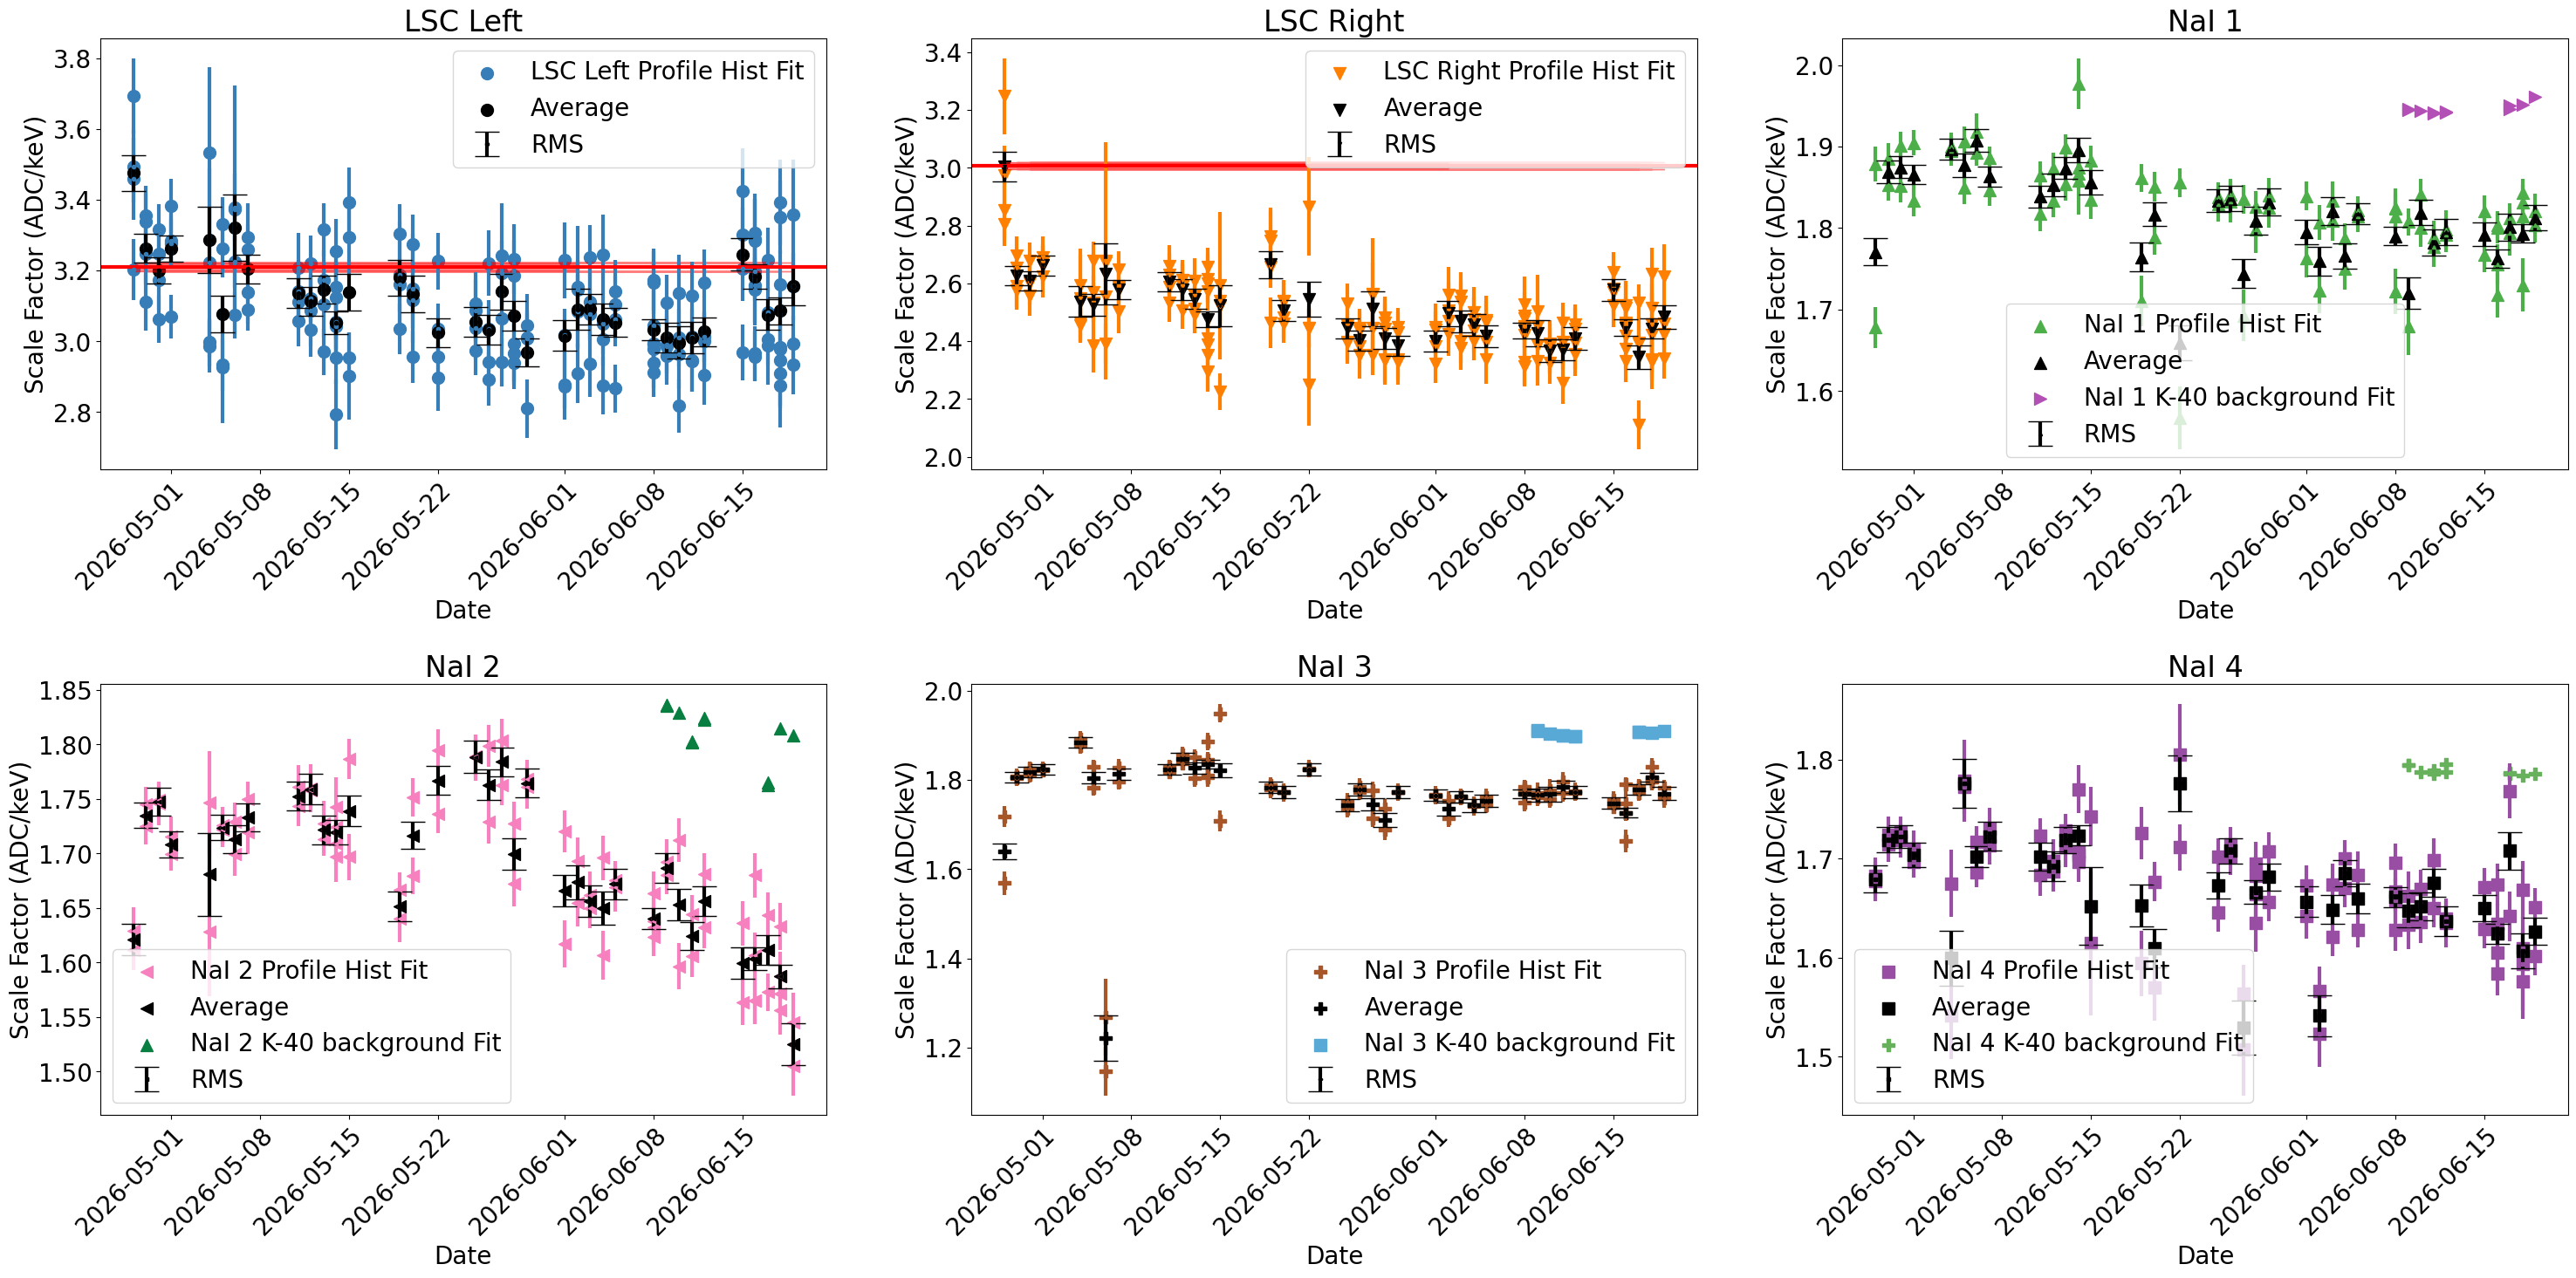

In [6]:
fig,ax = plt.subplots(2,3,figsize = (30,15))
plt.tight_layout()
plt.subplots_adjust(hspace = 0.5,wspace = 0.2,left = 0.04,bottom = 0.15)

channels = [4,5,8,10,12,14]
axesNum = [ax[0,0],ax[0,1],ax[0,2],ax[1,0],ax[1,1],ax[1,2]]
for data in totalData:
    axes = axesNum[channels.index(data.ch)]        
        
    data.plotData(axes,NaIcolourCode = False)
    data.plotAverageData(axes,plotstdev = False,plotErrProp = True)
    
for data in K40totalData:
    axes = axesNum[channels.index(data.ch)]
    
    data.plotData(axes,NaIcolourCode = False)
    
ax[0,0].axhline(LPMT[0], color = 'red')
ax[0,0].fill_between(x = totalData[0].dates,y1=LPMT[0]+LPMT[1], y2=LPMT[0]-LPMT[1], color='red',  interpolate=True, alpha=.5)

ax[0,1].axhline(RPMT[0], color = 'red')
ax[0,1].fill_between(x = totalData[0].dates,y1=RPMT[0]+RPMT[1], y2=RPMT[0]-RPMT[1], color='red',  interpolate=True, alpha=.5)
    
# labels = totalData[0].dates    

for i,axs in enumerate(axesNum):
    axs.set_title(f'{Detectors[f'Ch_{channels[i]}'][0]}')   
    axs.set_xlabel('Date')
    axs.set_ylabel('Scale Factor (ADC/keV)')
    axs.legend(loc = 'best')
    
    # Format x-axis to show only YYYY-MM-DD
    axs.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    plt.setp(axs.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    # ax.set_xticks(ticks)
    # axs.set_xticklabels(labels, rotation=45, ha='right', rotation_mode='anchor')
    # axs.tick_params(axis='x', labelrotation=45,ha='right')
    
# plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
plt.savefig('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/stability_figures/Annulus_Stability_plots.png', dpi = 300)
plt.savefig('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/stability_figures/Annulus_Stability_plots.pdf')
# plt.savefig('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/stability_figures/Annulus_Stability_plots.svg')
plt.show()



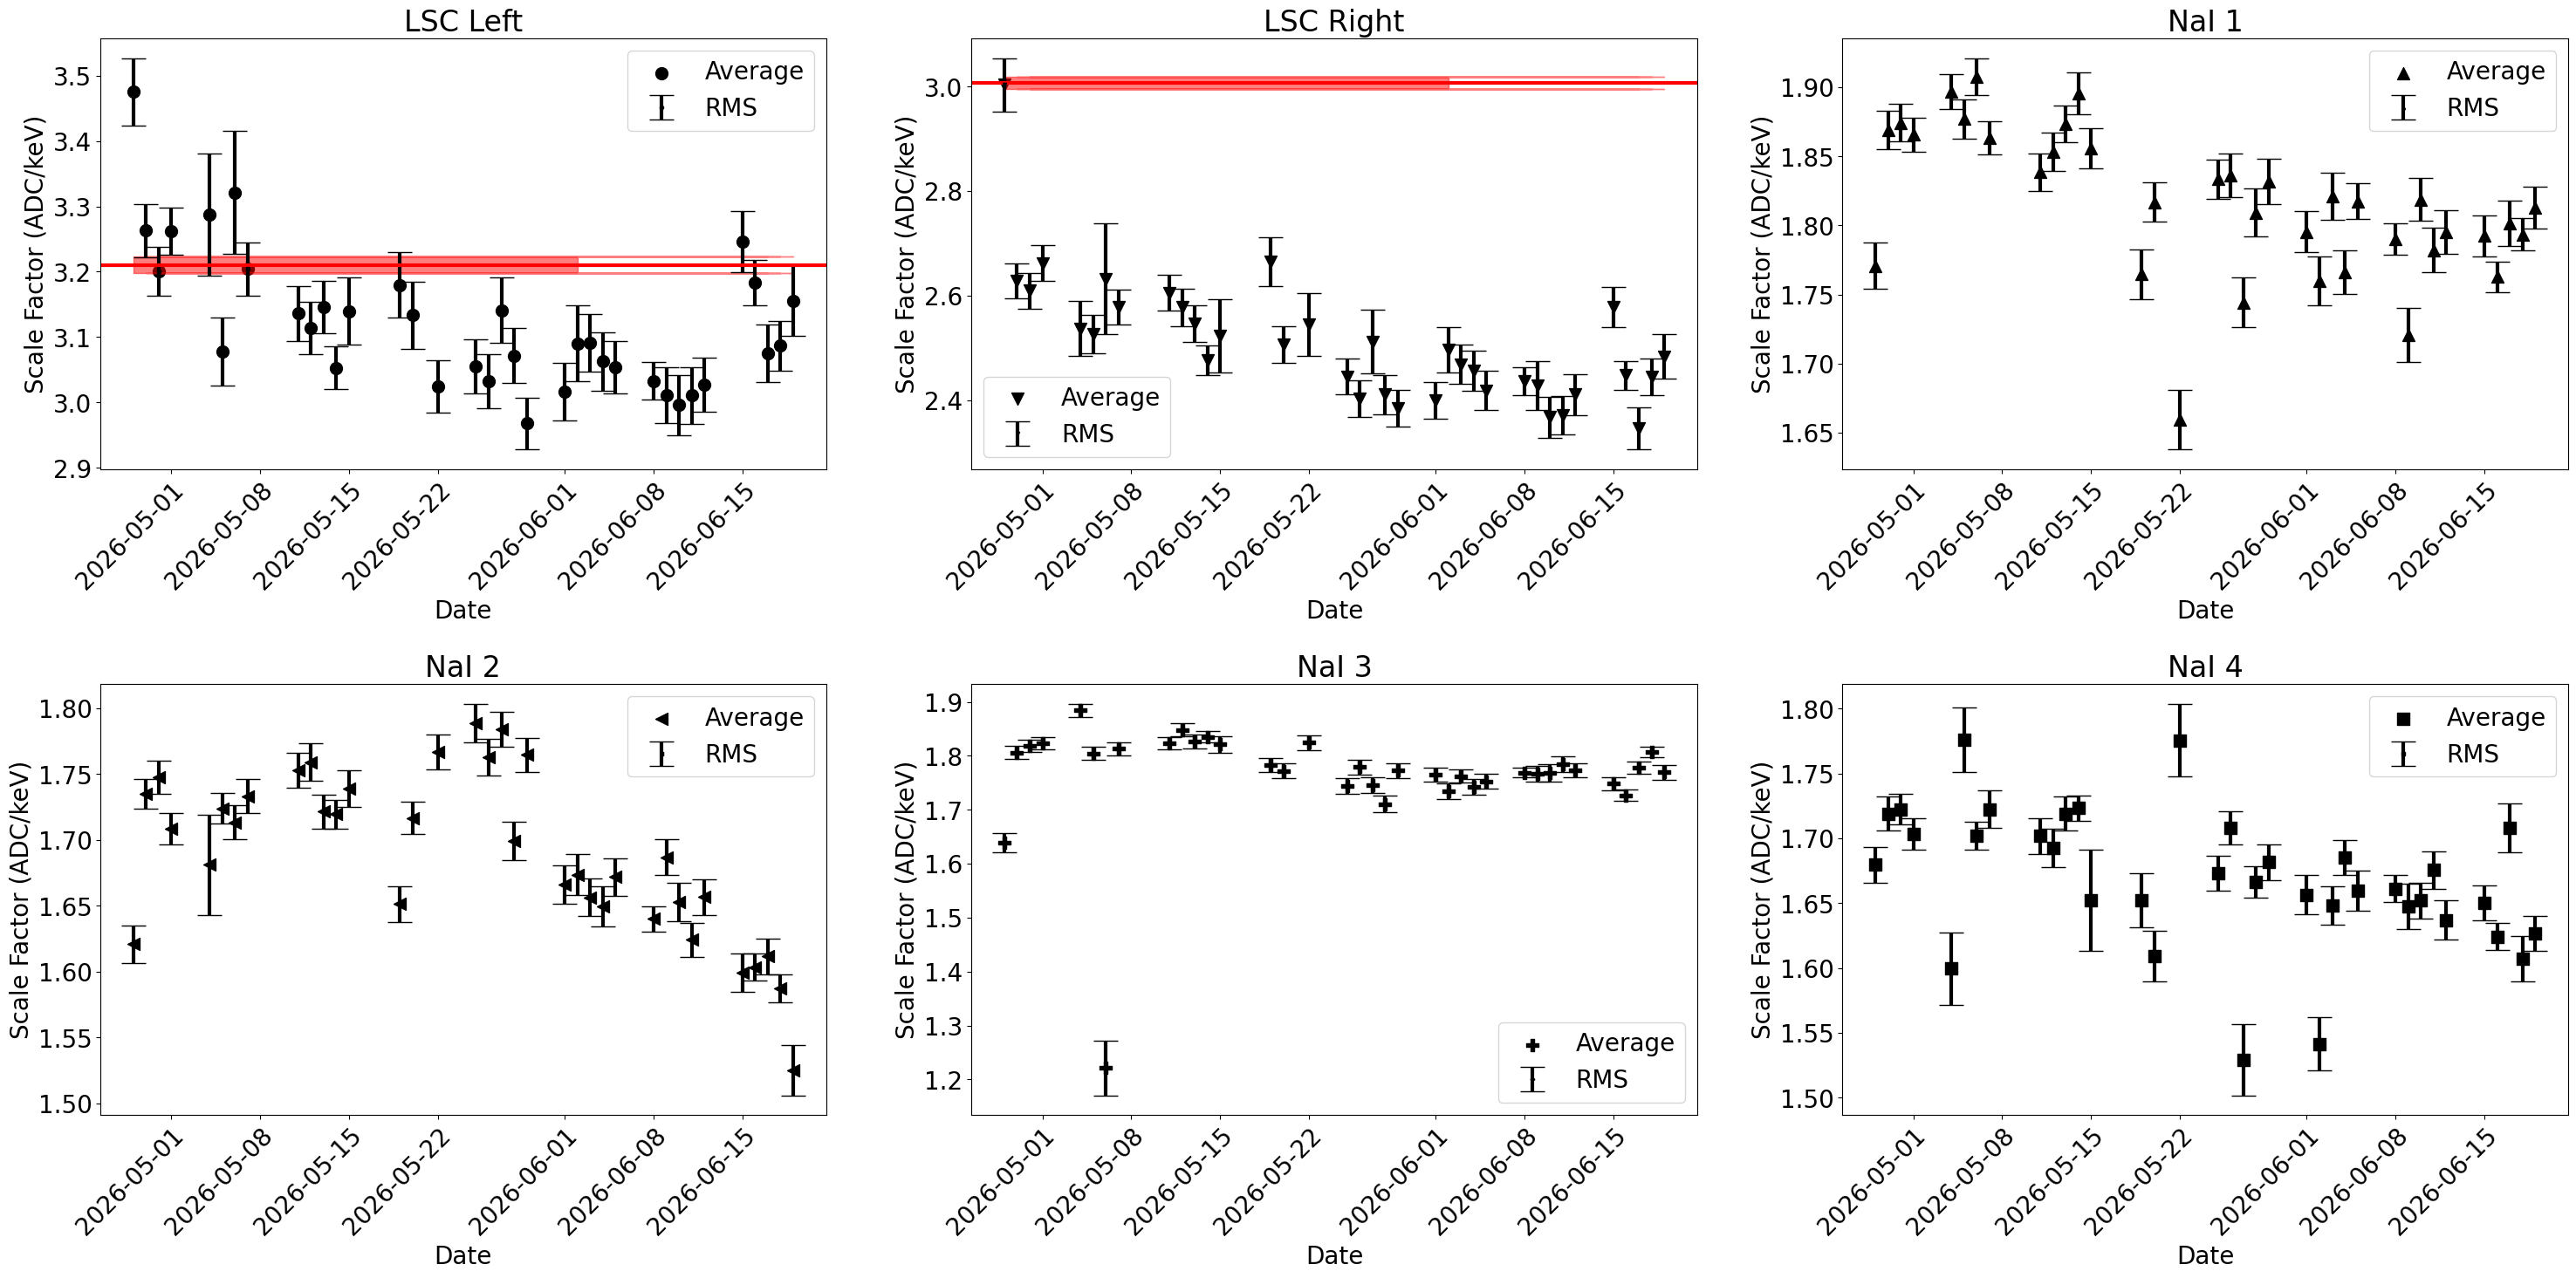

In [7]:
fig,ax = plt.subplots(2,3,figsize = (30,15))
plt.tight_layout()
plt.subplots_adjust(hspace = 0.5,wspace = 0.2,left = 0.04,bottom = 0.15)

channels = [4,5,8,10,12,14]
axesNum = [ax[0,0],ax[0,1],ax[0,2],ax[1,0],ax[1,1],ax[1,2]]
for data in totalData:
    axes = axesNum[channels.index(data.ch)]        
        
    # data.plotData(axes)
    data.plotAverageData(axes,plotstdev = False,plotErrProp = True)
    
ax[0,0].axhline(LPMT[0], color = 'red')
ax[0,0].fill_between(x = totalData[0].dates,y1=LPMT[0]+LPMT[1], y2=LPMT[0]-LPMT[1], color='red',  interpolate=True, alpha=.5)

ax[0,1].axhline(RPMT[0], color = 'red')
ax[0,1].fill_between(x = totalData[0].dates,y1=RPMT[0]+RPMT[1], y2=RPMT[0]-RPMT[1], color='red',  interpolate=True, alpha=.5)
    
# labels = totalData[0].dates    

for i,axs in enumerate(axesNum):
    axs.set_title(f'{Detectors[f'Ch_{channels[i]}'][0]}')   
    axs.set_xlabel('Date')
    axs.set_ylabel('Scale Factor (ADC/keV)')
    axs.legend(loc = 'best')
    
    # Format x-axis to show only YYYY-MM-DD
    axs.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    plt.setp(axs.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    # ax.set_xticks(ticks)
    # axs.set_xticklabels(labels, rotation=45, ha='right', rotation_mode='anchor')
    # axs.tick_params(axis='x', labelrotation=45,ha='right')
    
# plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
plt.savefig('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/stability_figures/Annulus_Stability_plots_average_data.png', dpi = 300)
plt.savefig('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/stability_figures/Annulus_Stability_plots_average_data.pdf')
plt.savefig('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/stability_figures/Annulus_Stability_plots_average_data.svg')
plt.show()

In [8]:
saveFilePath = rootFilePath / 'Results'
saveFilePath.mkdir(parents = True, exist_ok=True)

f = open(saveFilePath / 'Annulus_stability_data.txt', "w+")
f.write('Date, channel, Detector Name, Scale Factor (ADC/keV), Scale Factor Err (ADC/keV),coincident channel, coincident Detector\n')

for data in totalData:
    for s,serr,date,cCh in zip(data.scaleFactors,data.scaleFactorsErr,data.dates,data.coincChannel):
        f.write(f'{date},{data.ch},{Detectors[f'Ch_{data.ch}'][0]},{s},{serr},{cCh},{Detectors[f'Ch_{cCh}'][0]}\n')
        
f.close()


f = open(saveFilePath / 'Annulus_stability_data_average.txt', "w+")
f.write('Date, channel, Detector Name, Average Scale Factor (ADC/keV), Average Scale Factor Err (ADC/keV)\n')

for data in totalData:
    for s,serr,date,cCh in zip(data.averageData,data.averageErrors,data.averageDates,data.coincChannel):
        f.write(f'{date},{data.ch},{Detectors[f'Ch_{data.ch}'][0]},{s},{serr}\n')
        
f.close()
    
    
'''
self.averageDates = averageDates
self.averageData= averageData
self.averageErrors = averageErrors
self.averageErrorsstd = averageErrorsstd
'''

'\nself.averageDates = averageDates\nself.averageData= averageData\nself.averageErrors = averageErrors\nself.averageErrorsstd = averageErrorsstd\n'

In [51]:
mydict = {'0': 0,
          '1': 1,
          '2': 2,
          '3': 3,
          '4': 4,
          '5': 5}

for i, d in enumerate(mydict):
    print(i)
    print(d)

0
0
1
1
2
2
3
3
4
4
5
5
